In [27]:
import pandas as pd

# 1. Load the two datasets
df_trees = pd.read_csv('trees_within_radius.csv')
df_crown = pd.read_csv('crown_area_interpolated_final.csv')

# now make average crown area per species
df_crown 

,Unnamed: 0,OBJECTID,SITE_NAME,X,Y,EXTENT_EASTING_1,EXTENT_NORTHING_1,EXTENT_EASTING_2,EXTENT_NORTHING_2,LATIN_NAME,COMMON_NAME,FULL_COMMON_NAME,TREE_SPECIES,CROWN_WIDTH,CROWN_HEIGHT,DBH,PLANTING_SEASON,CROWN_AREA_MIDPOINT,CROWN_AREA_COMPLETE
0,0,26609351,Dovercourt Road To Muller Road Footpath,359956.40,176260.01,359956.40,176260.01,359956.40,176260.01,Fraxinus excelsior,Ash,Common ash,Fraxinus excelsior,14.0,15.0,NaN,Not Applicable,NaN,NaN
1,1,26609352,Dovercourt Road To Muller Road Footpath,359933.76,176296.56,359933.76,176296.56,359933.76,176296.56,Prunus - Species Unknown,Cherry,Unidentified cherry,Prunus - Species Unknown,NaN,NaN,NaN,Not Applicable,NaN,NaN
2,2,26609353,Eastville Roundabout M32 Junction 2,361186.30,175261.56,361186.30,175261.56,361186.30,175261.56,Metasequoia glyptostroboides,Dawn Redwood,Dawn redwood,Metasequoia glyptostroboides,1.0,4.0,0.07,Planting Season 08/09,10.00,10.00
3,3,26609354,Eastville Roundabout M32 Junction 2,361181.52,175236.67,361181.52,175236.67,361181.52,175236.67,Metasequoia glyptostroboides,Dawn Redwood,Dawn redwood,Metasequoia glyptostroboides,1.0,4.0,0.06,Planting Season 08/09,10.00,10.00
4,4,26609355,Eastville Roundabout M32 Junction 2,361164.98,175223.73,361164.98,175223.73,361164.98,175223.73,Metasequoia glyptostroboides,Dawn Redwood,Dawn redwood,Metasequoia glyptostroboides,NaN,NaN,NaN,Not Applicable,NaN,NaN
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
55077,55077,26665022,Harptree Grove,357866.78,170853.97,357866.78,170853.97,357866.78,170853.97,Acer pseudoplatanus,Sycamore,Sycamore,Acer pseudoplatanus,6.0,8.0,0.32,Not Applicable,60.05,60.05
55078,55078,26665023,Harptree Grove,357867.89,170860.00,357867.89,170860.00,357867.89,170860.00,Acer pseudoplatanus,Sycamore,Sycamore,Acer pseudoplatanus,7.0,8.0,0.32,Not Applicable,60.05,60.05
55079,55079,26665024,Harptree Grove,357870.10,170864.07,357870.10,170864.07,357870.10,170864.07,Acer pseudoplatanus,Sycamore,Sycamore,Acer pseudoplatanus,7.0,8.0,0.35,Not Applicable,60.05,60.05
55080,55080,26665025,Harptree Grove,357873.44,170868.63,357873.44,170868.63,357873.44,170868.63,Acer pseudoplatanus,Sycamore,Sycamore,Acer pseudoplatanus,7.0,9.0,0.34,Not Applicable,60.05,60.05


In [28]:
df = df_crown

# 1. Define your evergreen set
evergreen_set = {
    "Bay", "Box", "Cabbage Palm", "Cedar", "Chusan Palm", "Conifer", "Cypress", "Douglas Fir", "Eleagnus",
    "Eucalyptus", "Feijoa", "Fir", "Firethorn", "Hiba", "Hemlock", "Holly", "Juniper", "Laurel", "Monkey Puzzle",
    "Pine", "Pittosporum", "Redwood", "Scots Pine", "Spruce", "Strawberry Tree", "Wedding Cake Tree", "Yew"
}

# (Assuming your dataframe is already loaded as 'df')

# --- INITIAL CHECK ---
missing_before = df['CROWN_AREA_COMPLETE'].isna().sum()
print(f"NaNs to fill: {missing_before}")

# --- PHASE 1: Species-Specific Averages ---
# Calculate the mean for each species and create a matching series
species_means = df.groupby('COMMON_NAME')['CROWN_AREA_COMPLETE'].transform('mean')

# Fill NaNs in the target column using the species_means series
df['CROWN_AREA_COMPLETE'] = df['CROWN_AREA_COMPLETE'].fillna(species_means)


# --- PHASE 2: Fallback to Evergreen/Deciduous Averages ---
# Create a temporary column to classify every tree as Evergreen or Deciduous
# We use .isin() for a fast, clean check against your set
df['Tree_Type'] = df['COMMON_NAME'].apply(lambda x: 'Evergreen' if x in evergreen_set else 'Deciduous')

# Calculate the mean for both types based on the CURRENT state of the data
type_means = df.groupby('Tree_Type')['CROWN_AREA_COMPLETE'].transform('mean')

# Fill any remaining NaNs (where a species had no numeric data at all) with the type mean
df['CROWN_AREA_COMPLETE'] = df['CROWN_AREA_COMPLETE'].fillna(type_means)


# --- CLEANUP AND VERIFY ---
# Drop the temporary Tree_Type column to keep your dataframe exactly as it was
df = df.drop(columns=['Tree_Type'])

missing_after = df['CROWN_AREA_COMPLETE'].isna().sum()
print(f"NaNs remaining: {missing_after} (Should be 0!)")

# Save your work
df.to_csv('imputed_crown_areas.csv', index=False)

NaNs to fill: 3152
NaNs remaining: 0 (Should be 0!)


Plot saved successfully as 'DBH_vs_CrownArea_RedImputed.png'


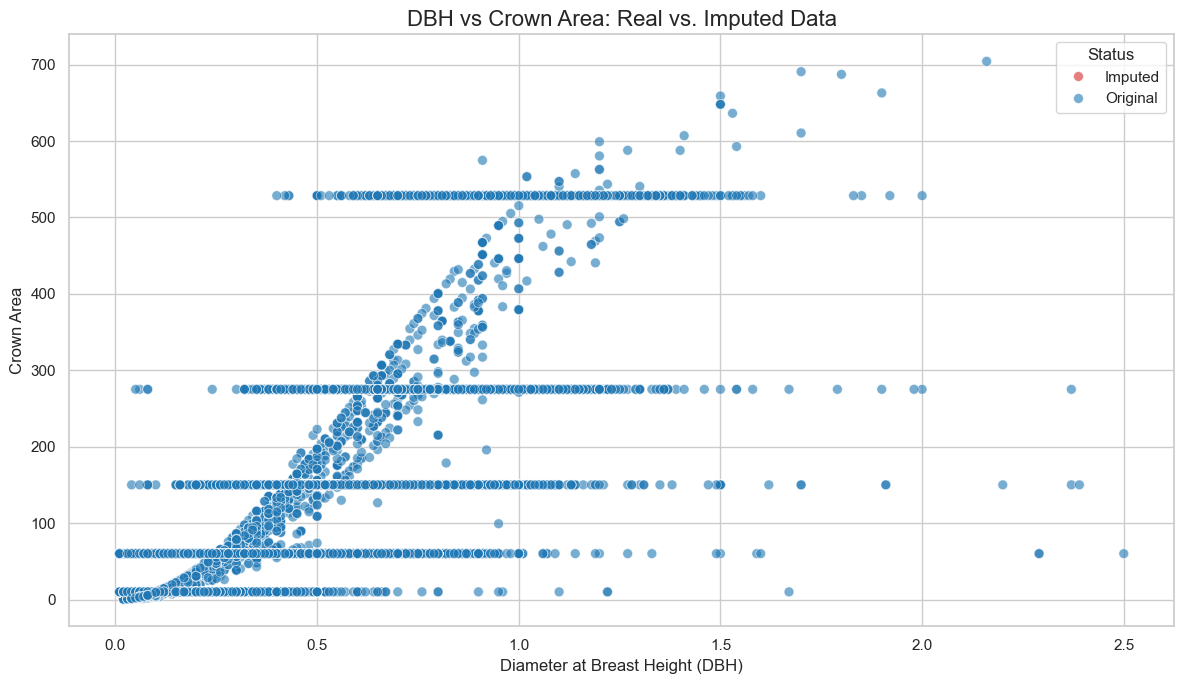

In [31]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# 1. Load BOTH datasets
# (Update 'crown_area_within_radii.csv' if your original file had a different name by this step)
df_original = pd.read_csv('crown_area_interpolated_final.csv') 
df_imputed = pd.read_csv('imputed_crown_areas.csv')

# 2. Create a tag for the data
# np.where works like an IF statement: IF original was NaN -> 'Imputed', ELSE -> 'Original'
df_imputed['Data Source'] = np.where(df_original['CROWN_AREA_COMPLETE'].isna(), 'Imputed', 'Original')

# 3. Set up the plot
plt.figure(figsize=(12, 7))
sns.set_theme(style="whitegrid")

# 4. Create the scatter plot
# We use the 'Data Source' column for the hue (color)
sns.scatterplot(
    data=df_imputed, 
    x='DBH', 
    y='CROWN_AREA_COMPLETE', 
    hue='Data Source', 
    palette={'Original': '#1f77b4', 'Imputed': '#d62728'}, # Blue for real, Red for imputed
    alpha=0.6, # Slight transparency 
    s=50       # Dot size
)

# 5. Format and save
plt.title('DBH vs Crown Area: Real vs. Imputed Data', fontsize=16)
plt.xlabel('Diameter at Breast Height (DBH)', fontsize=12)
plt.ylabel('Crown Area', fontsize=12)

plt.legend(title='Status')
plt.tight_layout()
plt.savefig('DBH_vs_CrownArea_RedImputed.png', dpi=300)

print("Plot saved successfully as 'DBH_vs_CrownArea_RedImputed.png'")

In [29]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# 1. Load the newly imputed dataset
df = pd.read_csv('imputed_crown_areas.csv')

# 2. Set up the plot style
plt.figure(figsize=(14, 8))
sns.set_theme(style="whitegrid")

# 3. Create the scatter plot
# x = DBH, y = Crown Area, hue = Color by Species
g = sns.relplot(
    data=df, 
    x='DBH', 
    y='CROWN_AREA_COMPLETE', 
    col='COMMON_NAME', 
    col_wrap=5, # 5 graphs per row
    height=3, 
    alpha=0.7
)

# 4. Format the chart
plt.title('DBH vs Crown Area (Checking Imputation)', fontsize=16)
plt.xlabel('Diameter at Breast Height (DBH)', fontsize=12)
plt.ylabel('Crown Area', fontsize=12)

# Move the legend outside the plot so it doesn't cover your data
plt.legend(bbox_to_anchor=(1.01, 1), loc='upper left', title='Species', borderaxespad=0)

# 5. Adjust layout and save the image
plt.tight_layout()
plt.savefig('DBH_vs_CrownArea_ImputationCheck.png', dpi=300)

print("Plot saved successfully as 'DBH_vs_CrownArea_ImputationCheck.png'")

KeyboardInterrupt: 

<Figure size 1400x800 with 0 Axes>

Error in callback <function flush_figures at 0x00000168F0978700> (for post_execute), with arguments args (),kwargs {}:


KeyboardInterrupt: 

In [ ]:
df

,Unnamed: 0,OBJECTID,SITE_NAME,X,Y,EXTENT_EASTING_1,EXTENT_NORTHING_1,EXTENT_EASTING_2,EXTENT_NORTHING_2,LATIN_NAME,COMMON_NAME,FULL_COMMON_NAME,TREE_SPECIES,CROWN_WIDTH,CROWN_HEIGHT,DBH,PLANTING_SEASON,CROWN_AREA_MIDPOINT,CROWN_AREA_COMPLETE
0,0,26609351,Dovercourt Road To Muller Road Footpath,359956.40,176260.01,359956.40,176260.01,359956.40,176260.01,Fraxinus excelsior,Ash,Common ash,Fraxinus excelsior,14.0,15.0,NaN,Not Applicable,NaN,101.542257
1,1,26609352,Dovercourt Road To Muller Road Footpath,359933.76,176296.56,359933.76,176296.56,359933.76,176296.56,Prunus - Species Unknown,Cherry,Unidentified cherry,Prunus - Species Unknown,NaN,NaN,NaN,Not Applicable,NaN,42.839905
2,2,26609353,Eastville Roundabout M32 Junction 2,361186.30,175261.56,361186.30,175261.56,361186.30,175261.56,Metasequoia glyptostroboides,Dawn Redwood,Dawn redwood,Metasequoia glyptostroboides,1.0,4.0,0.07,Planting Season 08/09,10.00,10.000000
3,3,26609354,Eastville Roundabout M32 Junction 2,361181.52,175236.67,361181.52,175236.67,361181.52,175236.67,Metasequoia glyptostroboides,Dawn Redwood,Dawn redwood,Metasequoia glyptostroboides,1.0,4.0,0.06,Planting Season 08/09,10.00,10.000000
4,4,26609355,Eastville Roundabout M32 Junction 2,361164.98,175223.73,361164.98,175223.73,361164.98,175223.73,Metasequoia glyptostroboides,Dawn Redwood,Dawn redwood,Metasequoia glyptostroboides,NaN,NaN,NaN,Not Applicable,NaN,38.357363
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
55077,55077,26665022,Harptree Grove,357866.78,170853.97,357866.78,170853.97,357866.78,170853.97,Acer pseudoplatanus,Sycamore,Sycamore,Acer pseudoplatanus,6.0,8.0,0.32,Not Applicable,60.05,60.050000
55078,55078,26665023,Harptree Grove,357867.89,170860.00,357867.89,170860.00,357867.89,170860.00,Acer pseudoplatanus,Sycamore,Sycamore,Acer pseudoplatanus,7.0,8.0,0.32,Not Applicable,60.05,60.050000
55079,55079,26665024,Harptree Grove,357870.10,170864.07,357870.10,170864.07,357870.10,170864.07,Acer pseudoplatanus,Sycamore,Sycamore,Acer pseudoplatanus,7.0,8.0,0.35,Not Applicable,60.05,60.050000
55080,55080,26665025,Harptree Grove,357873.44,170868.63,357873.44,170868.63,357873.44,170868.63,Acer pseudoplatanus,Sycamore,Sycamore,Acer pseudoplatanus,7.0,9.0,0.34,Not Applicable,60.05,60.050000


In [ ]:

# 2. Extract the target Object IDs from the TREES dataset
target_ids = df_trees['OBJECTID'].unique()

# 3. Filter the CROWN dataset 
# This keeps all columns in df_crown (including your extra one), 
# but only for the rows where the ObjectID was in the trees dataset.
df_result = df_crown[df_crown['OBJECTID'].isin(target_ids)]

# 4. Save the result to a new Excel file
df_result.to_excel('crown_area_filtered_output.xlsx', index=False)

print(f"Success! {len(df_result)} rows matched and saved with all crown area columns.")

In [ ]:
# 2. Filter the dataframe for rows where the area is less than 0
# Make sure the column name string exactly matches your file (spaces, caps, etc.)
negative_areas = df_result[df_result['CROWN_AREA_COMPLETE'] < 0]

# 3. Count how many times each species (COMMON_NAME) appears in this filtered list
species_counts = negative_areas['COMMON_NAME'].value_counts()

# 4. Print the results to your console
print("Number of negative crown areas per species:")
print(species_counts)

# Optional: Save this quick summary to a new CSV file so you have a record of it
#species_counts.to_csv('negative_areas_by_species.csv', header=['Count of Negatives'])

Number of negative crown areas per species:
Series([], Name: count, dtype: int64)
